
--- Iteration: 10 ---
New column(s) added with minimum reduced cost: -2.0

--- Iteration: 20 ---
New column(s) added with minimum reduced cost: -0.6428571428571435

--- Iteration: 30 ---
New column(s) added with minimum reduced cost: -0.400000000000001

--- Iteration: 40 ---
New column(s) added with minimum reduced cost: -0.4637681159420288

--- Iteration: 50 ---
New column(s) added with minimum reduced cost: -0.39999999999999947

--- Iteration: 60 ---
New column(s) added with minimum reduced cost: -0.19999999999999996

--- Iteration: 70 ---
New column(s) added with minimum reduced cost: -0.29090909090909967

--- Column Generation Complete ---
No more profitable columns found. Optimal LP solution reached.

Chromatic number: 3.0000000000000027


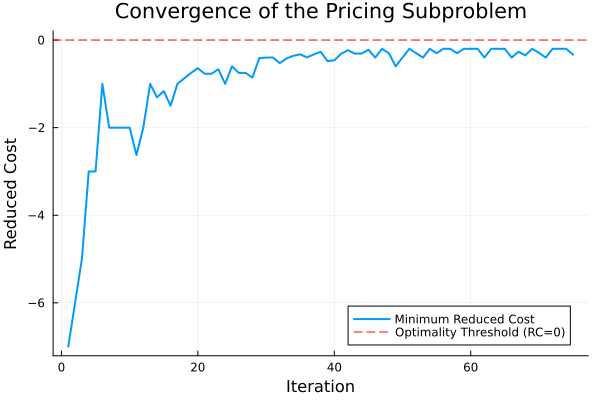

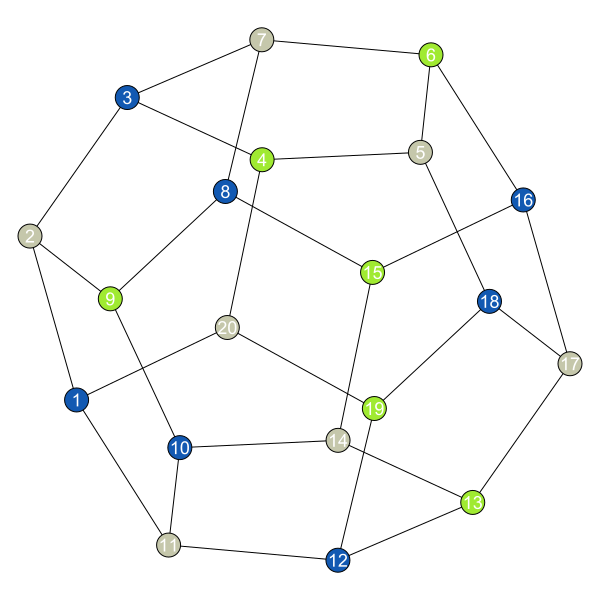

In [5]:
# -------------------------------------------------------------
#  Code for: "Introduction to Integer Programming and Applications with Julia"
#  Chapter: 6 – Graph problems
#  Section: Exercises 3.1 - 3.3
#  Author(s): Luiz Henrique Nogueira Lorena
# -------------------------------------------------------------

using JuMP       # Modeling language
using HiGHS      # Solver
using Plots      # For plotting
using Random     # For random number generation
using Graphs     # For graph data structures
using Karnak     # For graph visualization
using Colors     # For color handling

# Function to plot the convergence of reduced costs
function plot_reduced_costs(reduced_cost_history)
    p = Plots.plot(
        1:length(reduced_cost_history), 
        reduced_cost_history,
        label="Minimum Reduced Cost",
        xlabel="Iteration",
        ylabel="Reduced Cost",
        title="Convergence of the Pricing Subproblem",
        legend=:bottomright,
        linewidth=2
    )
    # Add a horizontal line at y=0 to show the convergence target
    Plots.hline!(p, [0], linestyle=:dash, color=:red, label="Optimality Threshold (RC=0)")
    # Display the plot
    display(p)
end

# Function to print the graph solution
function plot_solution(graph, solution = nothing)
    n = Graphs.nv(graph)
    if isnothing(solution)
        vertexfillcolors = fill(Colors.RGB(0, 0, 0), n)
    else
        colors = [Colors.RGB(rand(), rand(), rand()) for _ in 1:n]
        vertexfillcolors = [colors[solution[v]] for v in 1:n]
    end
    @drawsvg begin
        background("white")
        sethue("black")
        fontsize(18)
        drawgraph(
            graph,
            layout = stress,
            vertexshapesizes = 12,
            vertexlabels = 1:n,
            vertexfillcolors = vertexfillcolors
        )
    end
end

# Function to solve the master problem (RMP)
function master_problem(graph, columns; solve_as_integer=false)
    # Number of vertices and columns
    n = Graphs.nv(graph)
    n_columns = length(columns)
    
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)

    # Variables
    if solve_as_integer
        @variable(model, y[1:n_columns], Bin)
    else
        @variable(model, 0 <= y[1:n_columns] <= 1)
    end
    
    # Objective: Minimize the number of the selected columns
    @objective(model, Min, sum(y))

    # Constraint: Ensure that each vertex is covered by at least one selected column
    @constraint(model, cover_vertex[v=1:n], sum(y[j] for (j, col) in enumerate(columns) if v in col) >= 1)
    
    # Solve the model
    JuMP.optimize!(model)

    # Check the results and return dual prices
    if solve_as_integer
        if JuMP.termination_status(model) == JuMP.OPTIMAL
            return nothing, JuMP.value.(y), JuMP.objective_value(model)
        else
            error("Final integer problem did not solve to optimality. Status: $(JuMP.termination_status(model))")
        end
    else
        if JuMP.termination_status(model) == JuMP.OPTIMAL
            π = JuMP.dual.(cover_vertex)
            return π, nothing, nothing
        else
            error("RMP was not solved to optimality. Status: $(JuMP.termination_status(model))")
        end
    end
end

# Function to solve the pricing subproblem
function sub_problem(graph, columns, π)
    n = Graphs.nv(graph)
    
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    
    # Variables
    @variable(model, z[1:n], Bin)
    
    # Objective: Maximize the reduced cost
    @objective(model, Max, sum(π[v] * z[v] for v in 1:n))
    
    # Constraints: No two adjacent vertices can be in the same independent set
    for u in 1:n, v in Graphs.neighbors(graph, u)
        if u < v
            @constraint(model, z[u] + z[v] <= 1)
        end
    end

    # Solve the model
    JuMP.optimize!(model)

    # Check the results
    if JuMP.termination_status(model) == JuMP.OPTIMAL
        reduced_cost = 1 - JuMP.objective_value(model)
        new_column_found = reduced_cost < -1e-6
        # If a new column is found, extract it
        if new_column_found
            zval = JuMP.value.(z)
            new_colum = [v for v in 1:n if zval[v] ≥ 0.5]
            push!(columns, new_colum)
        end
        return new_column_found, reduced_cost
    else
        error("Pricing subproblem was not solved to optimality. Status: $(JuMP.termination_status(model))")
    end
end

# Function to solve the Graph Coloring Problem (GCP) using column generation
function solve_gcp_gc(graph; iterations = 100)

    # Vector to store reduced costs for each iteration
    reduced_cost_history = []

    # --- 1. Create initial columns ---
    columns = [[v] for v in 1:nv(graph)]

    # --- 2. Column generation loop ---
    for iteration in 1:iterations
    
        # --- 3. Solve the Restricted Master Problem (RMP) ---
        π, _, _ = master_problem(graph, columns, solve_as_integer = false)
        
        # --- 4. Solve the Pricing Subproblem ---
        new_column_found, reduced_cost = sub_problem(graph, columns, π)

        # --- 5. Check if a new pattern was found ---
        if !new_column_found || reduced_cost > -1e-6
            println("\n--- Column Generation Complete ---")
            println("No more profitable columns found. Optimal LP solution reached.")
            break
        else
            if iteration % 10 == 0
                println("\n--- Iteration: $iteration ---")
                println("New column(s) added with minimum reduced cost: $reduced_cost")
            end
            push!(reduced_cost_history, reduced_cost)
        end
    end

    # --- 6. Solve the Final Integer Problem ---
    _, y_values, chromatic_number = master_problem(graph, columns, solve_as_integer = true)

    println("\nChromatic number: ", chromatic_number)

    # --- 7. Generate reduced cost Plot ---
    plot_reduced_costs(reduced_cost_history)

    # --- 8. Post-process and display the final solution ---
    # Assign colors
    color_assign = zeros(Int, nv(graph))
    color_id = 1
    for (j, col) in enumerate(columns)
        if y_values[j] ≥ 0.5
            for v in col
                color_assign[v] = color_id
            end
            color_id += 1
        end
    end

    # Print the graph with colors
    plot_solution(graph, color_assign)
end

# Example usage:
Random.seed!(1)

# Create a sample graph (Dodecahedral graph)
graph = Graphs.smallgraph(:dodecahedral)

# Solve the GCP using column generation
solve_gcp_gc(graph, iterations = 1000)


--- Iteration: 10 ---
New column(s) added with minimum reduced cost: -1.3333333333333335

--- Iteration: 20 ---
New column(s) added with minimum reduced cost: -1.5

--- Iteration: 30 ---
New column(s) added with minimum reduced cost: -0.7573529411764777

--- Iteration: 40 ---
New column(s) added with minimum reduced cost: -0.4610389610389618

--- Iteration: 50 ---
New column(s) added with minimum reduced cost: -0.2918767507002813

--- Column Generation Complete ---
No more profitable columns found. Optimal LP solution reached.

Chromatic number: 4.0


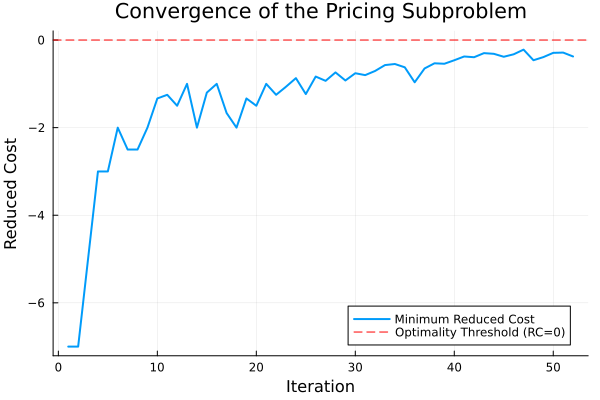

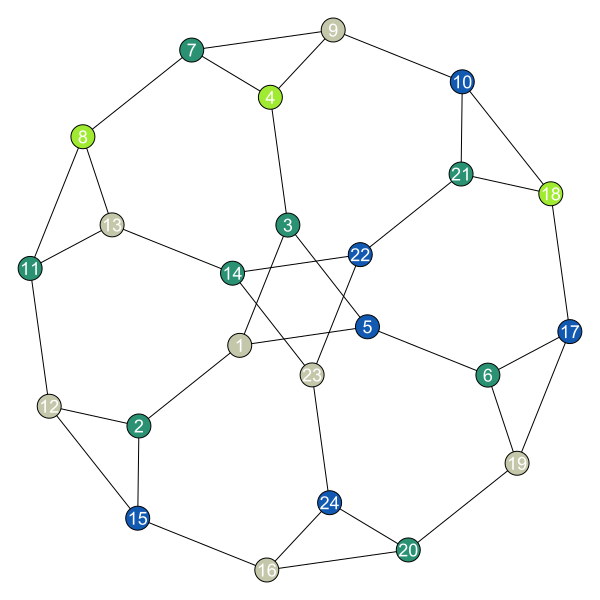

In [6]:
#  Section: Exercise 3.2

# Example usage:
Random.seed!(1)

# Create a sample graph (truncatedcube graph)
graph = Graphs.smallgraph(:truncatedcube)

# Solve the GCP using column generation
solve_gcp_gc(graph, iterations = 1000)


--- Iteration: 10 ---
New column(s) added with minimum reduced cost: -2.0

--- Iteration: 20 ---
New column(s) added with minimum reduced cost: -2.0

--- Iteration: 30 ---
New column(s) added with minimum reduced cost: -1.4999999999999996

--- Iteration: 40 ---
New column(s) added with minimum reduced cost: -1.4595469255663445

--- Iteration: 50 ---
New column(s) added with minimum reduced cost: -0.9196899224806176

--- Iteration: 60 ---
New column(s) added with minimum reduced cost: -0.7705470833962331

--- Iteration: 70 ---
New column(s) added with minimum reduced cost: -0.7301710223845346

--- Iteration: 80 ---
New column(s) added with minimum reduced cost: -0.6236797009041763

--- Iteration: 90 ---
New column(s) added with minimum reduced cost: -0.4541724220526555

--- Iteration: 100 ---
New column(s) added with minimum reduced cost: -0.4113309653515942

--- Iteration: 110 ---
New column(s) added with minimum reduced cost: -0.31395404928870096

--- Iteration: 120 ---
New column(s)

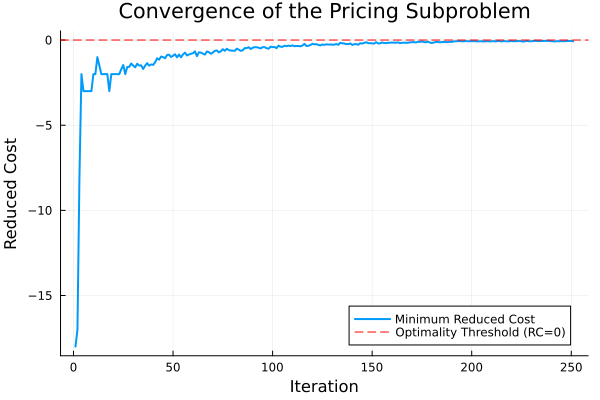

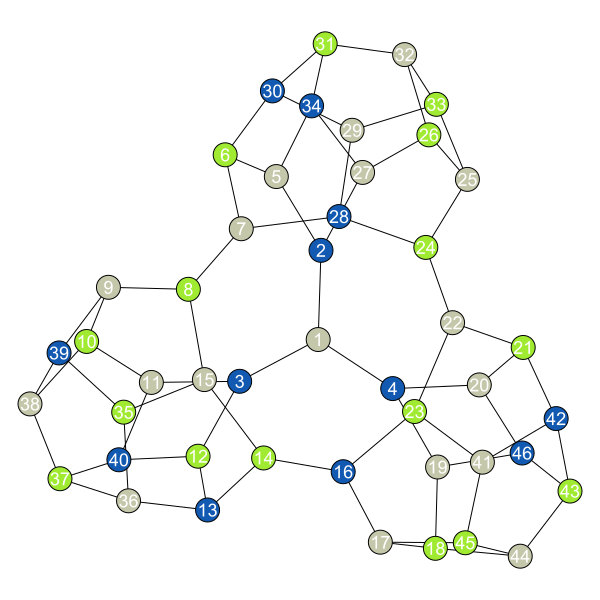

In [7]:
#  Section: Exercise 3.3

# Example usage:
Random.seed!(1)

# Create a sample graph (Dodecahedral graph)
graph = Graphs.smallgraph(:tutte)

# Solve the GCP using column generation
solve_gcp_gc(graph, iterations = 1000)